## Practice Lab 22- Recursive Neural Networks
In this lab we will look at Recursive Neural Networks. \
Based on Chapter 15 from Aurelien Geron's book, Hands-on Machine Learning with Scikit-Learn Keras & Tensorflow.\
Original code examples from book in github [here](https://github.com/ageron/handson-ml2)


<table align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/dtrad/geoml_course/blob/master/Practice22_RNN.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
</table>

In [1]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

try:
    # %tensorflow_version only exists in Colab.
    %tensorflow_version 2.x
    IS_COLAB = True
except Exception:
    IS_COLAB = False

# TensorFlow ≥2.0 is required
import tensorflow as tf
from tensorflow import keras
assert tf.__version__ >= "2.0"

if not tf.config.list_physical_devices('GPU'):
    print("No GPU was detected. LSTMs and CNNs can be very slow without a GPU.")
    if IS_COLAB:
        print("Go to Runtime > Change runtime and select a GPU hardware accelerator.")

# Add for GPU BEFORE JSON
from tensorflow.compat.v1 import ConfigProto
from tensorflow.compat.v1 import InteractiveSession

config = ConfigProto()
config.gpu_options.allow_growth = True
session = InteractiveSession(config=config)
####################################

        
# Common imports
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)
tf.random.set_seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt

## Exercise 1 - Predictions of time series using different methods
Using the time series generator below, predict future samples by using:
1) Linear regression\
2) Dense Neural network\
3) Recursive Neural network\
4) Deep Recursive Neural network\


In [3]:
def generate_time_series(batch_size, n_steps):
    freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
    time = np.linspace(0, 1, n_steps)
    series = 0.5 * np.sin((time - offsets1) * (freq1 * 10 + 10))  #   wave 1
    series += 0.2 * np.sin((time - offsets2) * (freq2 * 20 + 20)) # + wave 2
    series += 0.1 * (np.random.rand(batch_size, n_steps) - 0.5)   # + noise
    return series[..., np.newaxis].astype(np.float32)

Let us generate 7000 time series, each with 50 samples and an extra sample to predict (later we will predict more than one) 

In [4]:
np.random.seed(42)
n_steps = 50
series = generate_time_series(10000, n_steps + 1)
X_train, y_train = series[:7000, :n_steps], series[:7000, -1]
X_valid, y_valid = series[7000:9000, :n_steps], series[7000:9000, -1]
X_test, y_test = series[9000:, :n_steps], series[9000:, -1]

In [6]:
print(X_train.shape, X_valid.shape, X_test.shape)
print(y_train.shape, y_valid.shape, y_test.shape)

(7000, 50, 1) (2000, 50, 1) (1000, 50, 1)
(7000, 1) (2000, 1) (1000, 1)


In [6]:
print(y_train.shape, y_valid.shape, y_test.shape)

(7000, 1) (2000, 1) (1000, 1)


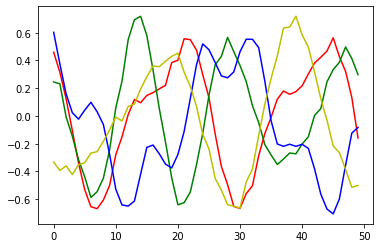

In [8]:
ts=[0,1,10,23]
plt.plot(X_train[ts[0],:,:],'r-')
plt.plot(X_train[ts[1],:,:],'g-')
plt.plot(X_train[ts[2],:,:],'b-')
plt.plot(X_train[ts[3],:,:],'y-')



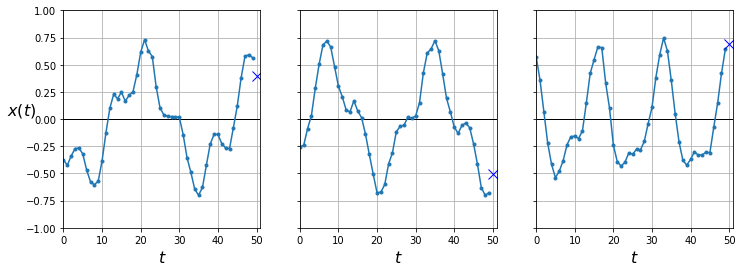

In [14]:
def plot_series(series, y=None, y_pred=None, x_label="$t$", y_label="$x(t)$"):
    plt.plot(series, ".-")
    if y is not None:
        plt.plot(n_steps, y, "bx", markersize=10)
    if y_pred is not None:
        plt.plot(n_steps, y_pred, "ro")
    plt.grid(True)
    if x_label:
        plt.xlabel(x_label, fontsize=16)
    if y_label:
        plt.ylabel(y_label, fontsize=16, rotation=0)
    plt.hlines(0, 0, 100, linewidth=1)
    plt.axis([0, n_steps + 1, -1, 1])

fig, axes = plt.subplots(nrows=1, ncols=3, sharey=True, figsize=(12, 4))
for col in range(3):
    plt.sca(axes[col])
    plot_series(X_valid[col, :, 0], y_valid[col, 0],
                y_label=("$x(t)$" if col==0 else None))

plt.show()

The simplest prediction we can do is to repeat the last sample

In [35]:
y_pred_naive=X_valid[:,-1]
np.mean(keras.losses.mean_squared_error(y_valid, y_pred_naive))

0.020211367

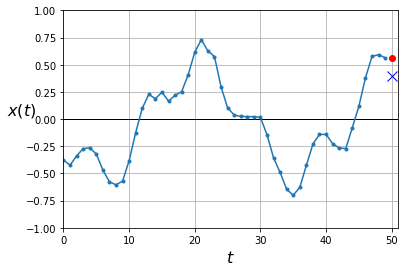

In [36]:
plot_series(X_valid[0, :, 0], y_valid[0, 0], y_pred_naive[0, 0])

Now let us make a linear prediction using a dense layer

In [30]:
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[50, 1]),
    keras.layers.Dense(1)
])

model.compile(loss="mse", optimizer="adam")
model.summary()

Model: "sequential_4"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_4 (Flatten)          (None, 50)                0         
_________________________________________________________________
dense_4 (Dense)              (None, 1)                 51        
Total params: 51
Trainable params: 51
Non-trainable params: 0
_________________________________________________________________


In [31]:
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_valid, y_valid))

Train on 7000 samples, validate on 2000 samples
Epoch 1/20
7000/7000 [==============================] - 1s 144us/sample - loss: 0.1004 - val_loss: 0.0559
Epoch 2/20
7000/7000 [==============================] - 0s 56us/sample - loss: 0.0386 - val_loss: 0.0269
Epoch 3/20
7000/7000 [==============================] - 0s 55us/sample - loss: 0.0205 - val_loss: 0.0162
Epoch 4/20
7000/7000 [==============================] - 0s 55us/sample - loss: 0.0133 - val_loss: 0.0118
Epoch 5/20
7000/7000 [==============================] - 0s 52us/sample - loss: 0.0104 - val_loss: 0.0098
Epoch 6/20
7000/7000 [==============================] - 0s 53us/sample - loss: 0.0089 - val_loss: 0.0087
Epoch 7/20
7000/7000 [==============================] - 0s 53us/sample - loss: 0.0080 - val_loss: 0.0078
Epoch 8/20
7000/7000 [==============================] - 0s 53us/sample - loss: 0.0073 - val_loss: 0.0071
Epoch 9/20
7000/7000 [==============================] - 0s 53us/sample - loss: 0.0066 - val_loss: 0.0065
Epoch 

Let us compare with the naive approach (copying the last sample)

In [34]:
print('MSE naive prediction',np.mean(keras.losses.mean_squared_error(y_valid, X_valid[:,-1])))
print('MSE error linear model',model.evaluate(X_valid, y_valid))

MSE naive prediction 0.30294636
2000/2000 [==============================] - 0s 41us/sample - loss: 0.0041
MSE error linear model 0.004145486194640398


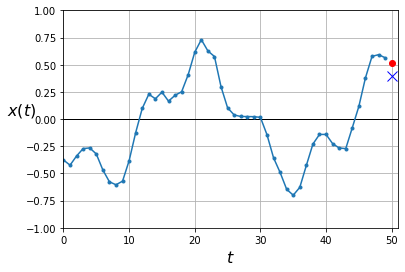

In [37]:
y_pred_DN = model.predict(X_valid)
plot_series(X_valid[0, :, 0], y_valid[0, 0], y_pred_DN[0, 0])

(<matplotlib.axes._subplots.AxesSubplot at 0x7f3db0290890>, None)

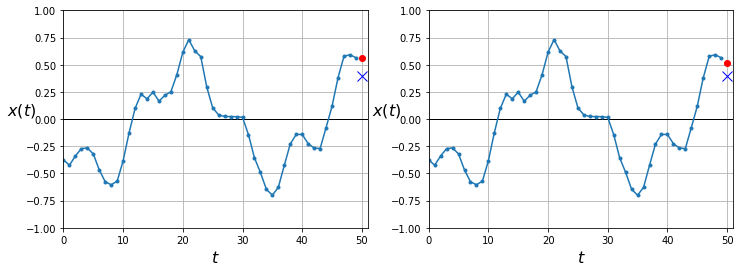

In [44]:
fig, axes = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(12, 4))
col=0
plt.subplot(121),plot_series(X_valid[col, :, 0], y_valid[col, 0], y_pred_naive[col, 0])
plt.subplot(122),plot_series(X_valid[col, :, 0], y_valid[col, 0], y_pred_DN[col, 0])

Now let us use a recursive neural network. Let start with the simplest possible,one layer and one neuron.

In [45]:
model = keras.models.Sequential([
    keras.layers.SimpleRNN(1, input_shape=[None, 1])
])

optimizer = keras.optimizers.Adam(lr=0.005)
model.compile(loss="mse", optimizer=optimizer)
history = model.fit(X_train, y_train, epochs=20,validation_data=(X_valid, y_valid))

Train on 7000 samples, validate on 2000 samples
Epoch 1/20
7000/7000 [==============================] - 6s 799us/sample - loss: 0.0312 - val_loss: 0.0126
Epoch 2/20
7000/7000 [==============================] - 4s 639us/sample - loss: 0.0118 - val_loss: 0.0111
Epoch 3/20
7000/7000 [==============================] - 4s 640us/sample - loss: 0.0115 - val_loss: 0.0109
Epoch 4/20
7000/7000 [==============================] - 5s 670us/sample - loss: 0.0114 - val_loss: 0.0109
Epoch 5/20
7000/7000 [==============================] - 4s 634us/sample - loss: 0.0114 - val_loss: 0.0109
Epoch 6/20
7000/7000 [==============================] - 4s 632us/sample - loss: 0.0114 - val_loss: 0.0109
Epoch 7/20
7000/7000 [==============================] - 4s 606us/sample - loss: 0.0114 - val_loss: 0.0109
Epoch 8/20
7000/7000 [==============================] - 4s 625us/sample - loss: 0.0114 - val_loss: 0.0109
Epoch 9/20
7000/7000 [==============================] - 4s 630us/sample - loss: 0.0114 - val_loss: 0.010

That took much longer than the DN. Let us evaluate it:

In [47]:
print('MSE naive prediction',np.mean(keras.losses.mean_squared_error(y_valid, X_valid[:,-1])))
print('MSE error RNN model',model.evaluate(X_valid, y_valid))

MSE naive prediction 0.30294636
2000/2000 [==============================] - 0s 175us/sample - loss: 0.0109
MSE error RNN model 0.010897529162466526


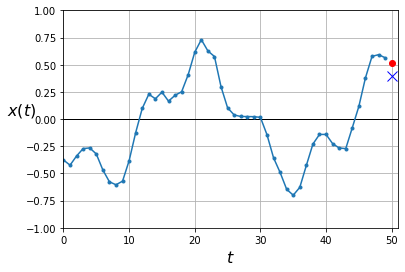

In [48]:
y_pred_RNN = model.predict(X_valid)
plot_series(X_valid[0, :, 0], y_valid[0, 0], y_pred_RNN[0, 0])

(<matplotlib.axes._subplots.AxesSubplot at 0x7f3d88522f10>, None)

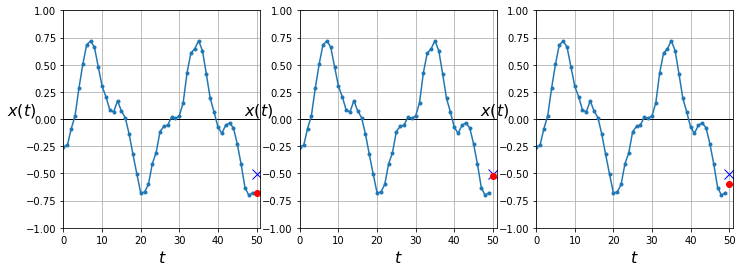

In [50]:
fig, axes = plt.subplots(nrows=1, ncols=3, sharey=True, figsize=(12, 4))
col=1
plt.subplot(131),plot_series(X_valid[col, :, 0], y_valid[col, 0], y_pred_naive[col, 0])
plt.subplot(132),plot_series(X_valid[col, :, 0], y_valid[col, 0], y_pred_DN[col, 0])
plt.subplot(133),plot_series(X_valid[col, :, 0], y_valid[col, 0], y_pred_RNN[col, 0])


The DN (linear) prediction is better than the RNN. Let us try more layers.

In [51]:
model = keras.models.Sequential([
    keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.SimpleRNN(20, return_sequences=True),
    keras.layers.SimpleRNN(1)
])

model.compile(loss="mse", optimizer="adam")
history = model.fit(X_train, y_train, epochs=20,validation_data=(X_valid, y_valid))

Train on 7000 samples, validate on 2000 samples
Epoch 1/20
7000/7000 [==============================] - 15s 2ms/sample - loss: 0.0181 - val_loss: 0.0053
Epoch 2/20
7000/7000 [==============================] - 14s 2ms/sample - loss: 0.0043 - val_loss: 0.0039
Epoch 3/20
7000/7000 [==============================] - 15s 2ms/sample - loss: 0.0035 - val_loss: 0.0032
Epoch 4/20
7000/7000 [==============================] - 15s 2ms/sample - loss: 0.0032 - val_loss: 0.0031
Epoch 5/20
7000/7000 [==============================] - 14s 2ms/sample - loss: 0.0030 - val_loss: 0.0028
Epoch 6/20
7000/7000 [==============================] - 13s 2ms/sample - loss: 0.0030 - val_loss: 0.0028
Epoch 7/20
7000/7000 [==============================] - 14s 2ms/sample - loss: 0.0029 - val_loss: 0.0027
Epoch 8/20
7000/7000 [==============================] - 14s 2ms/sample - loss: 0.0029 - val_loss: 0.0027
Epoch 9/20
7000/7000 [==============================] - 14s 2ms/sample - loss: 0.0029 - val_loss: 0.0027
Epoch 1

In [52]:
print('MSE naive prediction',np.mean(keras.losses.mean_squared_error(y_valid, X_valid[:,-1])))
print('MSE error RNN model',model.evaluate(X_valid, y_valid))

MSE naive prediction 0.020211367
2000/2000 [==============================] - 1s 475us/sample - loss: 0.0027
MSE error RNN model 0.0026991884578019382


In [53]:
y_pred_DRNN = model.predict(X_valid)

(<matplotlib.axes._subplots.AxesSubplot at 0x7f3d6824c650>, None)

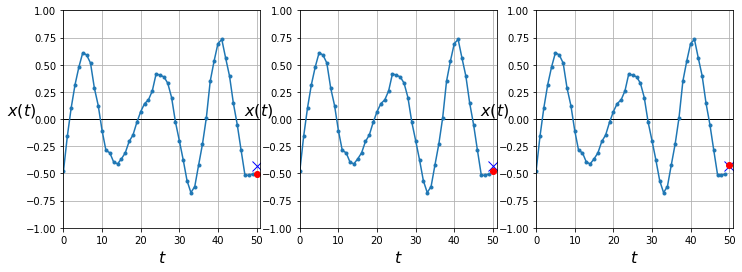

In [56]:
fig, axes = plt.subplots(nrows=1, ncols=3, sharey=True, figsize=(12, 4))
col=21
plt.subplot(131),plot_series(X_valid[col, :, 0], y_valid[col, 0], y_pred_naive[col, 0])
plt.subplot(132),plot_series(X_valid[col, :, 0], y_valid[col, 0], y_pred_DN[col, 0])
plt.subplot(133),plot_series(X_valid[col, :, 0], y_valid[col, 0], y_pred_DRNN[col, 0])

The predictions are good, but it is getting quite expensive (a lot more than the DN).\
To justify the cost, we have to look at more difficult tasks. 
We will now try to estimate several steps ahead. We could do this in two ways:
1) We predict one sample, put it in, predict the next.\
2) We predict all samples in the gap simultaneously.

In [ ]:
def plot_multiple_forecasts(X, Y, Y_pred):
    n_steps = X.shape[1]
    print(n_steps)
    ahead = Y.shape[1]
    print(ahead)
    plot_series(X[0, :, 0])
    plt.plot(np.arange(n_steps, n_steps + ahead), Y[0, :, 0], "ro-", label="Actual")
    plt.plot(np.arange(n_steps, n_steps + ahead), Y_pred[0, :, 0], "bx-", label="Forecast", markersize=10)
    plt.axis([0, n_steps + ahead, -1, 1])
    plt.legend(fontsize=14)

plot_multiple_forecasts(X_valid, y_valid, y_pred)